In [39]:
import pandas as pd
import numpy as np
import mne

full_eeg_df = pd.read_csv("thetaEEG_full_2back_demo.csv")
eeg_lsl_starttime = 1783420.5204828 # NOT calibration complete
full_eeg_df["Time"] = full_eeg_df["Time"] + eeg_lsl_starttime
target_timestamp = np.array([1783460.6038521, 1783467.9537836, 1783475.2202884, 1783482.676686 ,1783493.0251028]) # when LIFU Sonicated
pre = 2
post = 2
windows = []
for idx, event in enumerate(target_timestamp): 
    mask = (full_eeg_df['Time'] >= (event - pre)) & (full_eeg_df['Time'] <= (event + post))
    window_df = full_eeg_df.loc[mask].copy()
    window_df["t_rel"] = window_df["Time"] - event 
    window_df["idx"] = idx
    windows.append(window_df)
#windows has 3 dataframes in one -- index them
first_data = windows[0]
first_data = first_data.drop(columns = ['t_rel', 'idx','Time'])
first_data

,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08
9521,-2229.380859,-21572.042969,-10898.734375,-5063.677246,-200000.0,-13444.997070,125200.289062,-18351.031250
9522,-3186.130859,-21569.109375,-11831.474609,-6915.212402,-200000.0,-14129.331055,125019.984375,-15700.104492
9523,-3267.908203,-21262.697266,-12330.176758,-7897.616211,-200000.0,-14445.807617,125006.398438,-14920.379883
9524,-2274.394043,-21301.484375,-11253.906250,-5872.893555,-200000.0,-13707.615234,125193.039062,-17790.390625
9525,-2045.107056,-21564.984375,-10582.685547,-4738.807617,-200000.0,-13323.379883,125247.750000,-18841.718750
...,...,...,...,...,...,...,...,...
10516,-2902.507812,-22048.666016,11869.956055,-4517.674805,-200000.0,-13467.789062,132791.671875,-19171.884766
10517,-3222.394043,-22266.677734,11906.671875,-4519.105469,-200000.0,-13506.890625,132749.343750,-18664.312500
10518,-4250.860840,-22144.558594,10706.210938,-6859.303223,-200000.0,-14349.176758,132553.375000,-15609.934570
10519,-3881.669434,-21865.443359,10688.067383,-6872.487305,-200000.0,-14313.007812,132629.968750,-16160.012695


Creating RawArray with float64 data, n_channels=8, n_times=1000
    Range : 0 ... 999 =      0.000 ...     3.996 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 2 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuatio

C:\Users\jshin\AppData\Local\Temp\ipykernel_28236\1775735422.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
C:\Users\jshin\AppData\Local\Temp\ipykernel_28236\1775735422.py:37: RuntimeWarning: filter_length (1651) is longer than the signal (1000), distortion is likely. Reduce filter length or filter a longer signal.
  raw.notch_filter(60.)
C:\Users\jshin\AppData\Local\Temp\ipykernel_28236\1775735422.py:59: UserWarning: Zero value in spectrum for channel  Ch01
  psds, freqs = raw_clean.compute_psd(


  Channel  Theta (4–7 Hz)  Alpha (8–12 Hz)  Beta (13–30 Hz)  Gamma (30–40 Hz)
0    Ch01        0.000000         0.000000         0.000000          0.000000
1    Ch02      479.699365        24.757323         1.622722          0.448345
2    Ch03     1629.996341        44.990348         1.194917          0.086406
3    Ch04     2187.658267        69.339704         3.045828          0.752063
4    Ch05      168.382942        15.333862         1.042882          0.314003
5    Ch06      199.240736         6.003846         0.200144          0.032036
6    Ch07      137.771988        11.746680         0.730596          0.217437
7    Ch08     3722.873904       236.987919        15.733274          4.877978


<Figure size 1200x600 with 0 Axes>

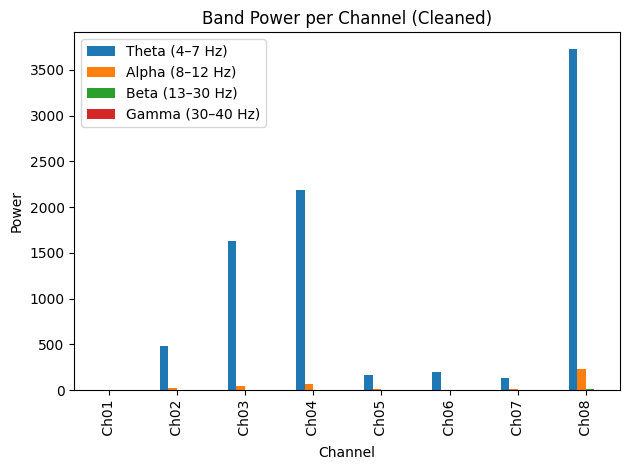

In [40]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. CLEAN RAW DATAFRAME (avoid drift‑creating interpolation)
# ---------------------------------------------------------
df = first_data.copy()

# Replace inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Fill short gaps only (limit=5 prevents long ramps)
df = df.interpolate(method='linear', limit=5, limit_direction='both')

# Final fill for any remaining NaN
df = df.fillna(method='bfill').fillna(method='ffill')

# ---------------------------------------------------------
# 2. BUILD MNE RAWARRAY
# ---------------------------------------------------------
sfreq = 250
data = df.values.T
ch_names = list(df.columns)

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# ---------------------------------------------------------
# 3. FILTERING (fix theta inflation)
# ---------------------------------------------------------
# High‑pass at 2 Hz removes drift that inflates theta
raw.filter(2., 40., fir_design='firwin')

# Notch 60 Hz
raw.notch_filter(60.)

# Use a stable reference (average ref is unstable with 8 channels)
raw.set_eeg_reference(ref_channels=[ch_names[0]])

# ---------------------------------------------------------
# 4. OPTIONAL: LIGHT ICA (ONLY if needed)
# ---------------------------------------------------------
# ICA on 8 channels is unstable — skip unless absolutely needed
# If you want ICA, uncomment below:

# ica = mne.preprocessing.ICA(n_components=8, random_state=97, max_iter='auto')
# ica.fit(raw)
# ica.exclude = []  # manually inspect before excluding
# raw_clean = ica.apply(raw.copy())

# For now, use raw directly:
raw_clean = raw.copy()

# ---------------------------------------------------------
# 5. PSD
# ---------------------------------------------------------
psds, freqs = raw_clean.compute_psd(
    fmin=2,
    fmax=40,
    n_fft=512
).get_data(return_freqs=True)

# ---------------------------------------------------------
# 6. BANDPOWER
# ---------------------------------------------------------
def band_power(psds, freqs, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return psds[:, mask].mean(axis=1)

theta = band_power(psds, freqs, 4, 7)
alpha = band_power(psds, freqs, 8, 12)
beta  = band_power(psds, freqs, 13, 30)
gamma = band_power(psds, freqs, 30, 40)

# ---------------------------------------------------------
# 7. RESULTS DATAFRAME
# ---------------------------------------------------------
bands_df = pd.DataFrame({
    'Channel': ch_names,
    'Theta (4–7 Hz)': theta,
    'Alpha (8–12 Hz)': alpha,
    'Beta (13–30 Hz)': beta,
    'Gamma (30–40 Hz)': gamma
})

print(bands_df)

# ---------------------------------------------------------
# 8. PLOT
# ---------------------------------------------------------
plt.figure(figsize=(12,6))
bands_df.set_index('Channel').plot(kind='bar')
plt.ylabel('Power')
plt.title('Band Power per Channel (Cleaned)')
plt.tight_layout()
plt.show()


In [41]:
raw_clean.compute_psd()

Effective window size : 4.000 (s)


C:\Users\jshin\AppData\Local\Temp\ipykernel_28236\241616019.py:1: UserWarning: Zero value in spectrum for channel  Ch01
  raw_clean.compute_psd()


<Power Spectrum (from Raw, welch method) | 8 channels × 501 freqs, 0.0-125.0 Hz>